In [13]:
import os
import pickle
from collections import defaultdict

folder = "/xcfhome/ypxia/Workspace/BioMPNN/record/backbone_test"

# 用 defaultdict(list) 收集每个 key 的数据
aggregated_data = defaultdict(list)

# 遍历文件夹里的所有 pkl 文件
for filename in os.listdir(folder):
    if filename.endswith(".pkl"):
        file_path = os.path.join(folder, filename)
        with open(file_path, "rb") as f:
            data = pickle.load(f)
            for key, value in data.items():
                aggregated_data[key].append(value)


In [14]:
mu, sigma, res_plddt, res_plddt_std, mask = [], [], [], [], []

result_dict = {
    "mu": mu,
    "sigma": sigma,
    "res_plddt": res_plddt,
    "res_plddt_std": res_plddt_std,
    "mask": mask,
}

for key, batches in aggregated_data.items():
    if key not in result_dict:
        continue
    for batch in batches:
        if hasattr(batch, "tolist"):
            batch_list = batch.tolist()
        else:
            batch_list = list(batch)
        result_dict[key].extend(batch_list)

In [15]:
for i in range(len(result_dict['mask'])):
    length = int( sum( result_dict['mask'][0] ) )
    result_dict['mu'][i][:length]
    result_dict['sigma'][i][:length]
    result_dict['res_plddt'][i][:length]
    result_dict['res_plddt_std'][i][:length]

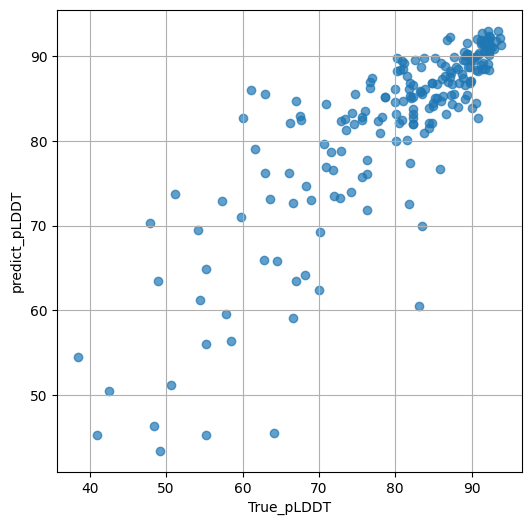

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 存储每条样本的平均值
mu_avg = []
res_plddt_avg = []

for i in range(len(result_dict['mask'])):
    mask_array = np.array(result_dict['mask'][i])
    length = int(mask_array.sum())

    mu_data = np.array(result_dict['mu'][i])[:length]
    res_plddt_data = np.array(result_dict['res_plddt'][i])[:length]

    mu_avg.append(mu_data.mean())
    res_plddt_avg.append(res_plddt_data.mean())

mu_avg = np.array(mu_avg)
res_plddt_avg = np.array(res_plddt_avg)

plt.figure(figsize=(6,6))
plt.scatter(res_plddt_avg, mu_avg, alpha=0.7)
plt.xlabel("True_pLDDT")
plt.ylabel("predict_pLDDT")

plt.grid(True)
plt.show()

In [17]:
import numpy as np

mu_avg = np.array(mu_avg)
res_plddt_avg = np.array(res_plddt_avg)

# 相关系数矩阵
corr = np.corrcoef(mu_avg, res_plddt_avg)

# 取非对角元素
pearson_r = corr[0, 1]

print(pearson_r)

0.8376301471034591


In [18]:
np.mean(np.abs(mu_avg - res_plddt_avg))

4.701322337534708

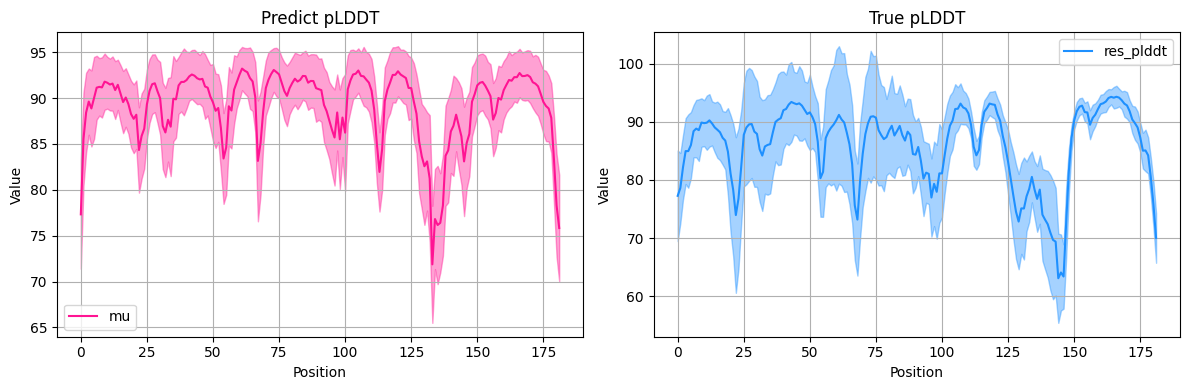

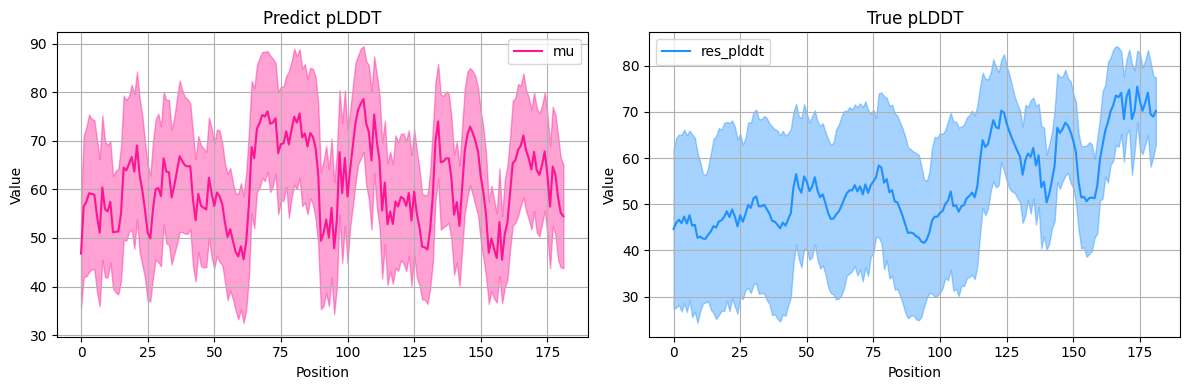

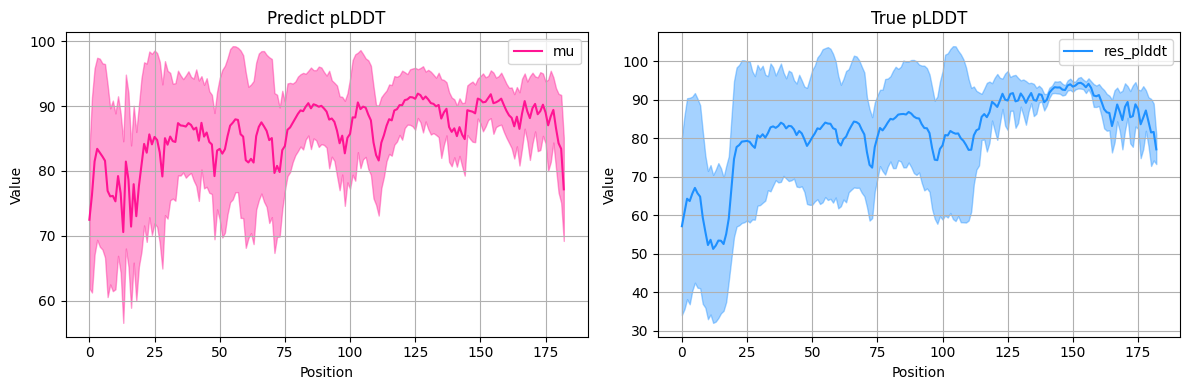

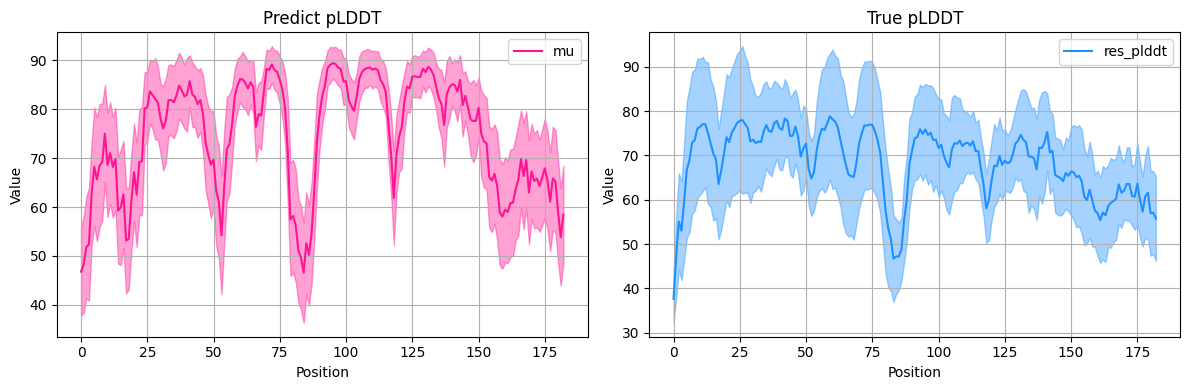

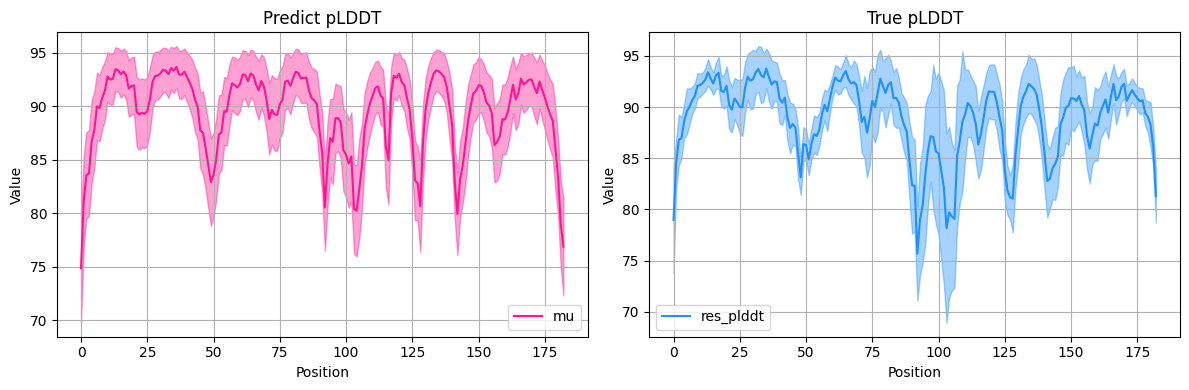

In [54]:
import matplotlib.pyplot as plt
import numpy as np

num_to_plot = 5

for i in range(num_to_plot):
    mask_array = np.array(result_dict['mask'][i])
    length = int(mask_array.sum())

    # 数据
    mu_data = np.array(result_dict['mu'][i])[:length]
    sigma_data = np.array(result_dict['sigma'][i])[:length]

    res_plddt_data = np.array(result_dict['res_plddt'][i])[:length]
    res_plddt_std_data = np.array(result_dict['res_plddt_std'][i])[:length]

    x = np.arange(length)

    # 创建横向子图
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 左：mu ± sigma
    axes[0].plot(x, mu_data, color='deeppink', label='mu')
    axes[0].fill_between(x, mu_data - sigma_data, mu_data + sigma_data, color='deeppink', alpha=0.4)
    axes[0].set_xlabel('Position')
    axes[0].set_ylabel('Value')
    axes[0].set_title('Predict pLDDT')
    axes[0].legend()
    axes[0].grid(True)

    # 右：res_plddt ± res_plddt_std
    axes[1].plot(x, res_plddt_data, color='dodgerblue', label='res_plddt')
    axes[1].fill_between(x, res_plddt_data - res_plddt_std_data, res_plddt_data + res_plddt_std_data, 
                         color='dodgerblue', alpha=0.4)
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('Value')
    axes[1].set_title('True pLDDT')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
